In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import TimeSeriesSplit
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import joblib

In [2]:
df_original = pd.read_csv("LLAN0095_total.csv")

In [3]:
df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 949041 entries, 0 to 949040
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Date              949041 non-null  object 
 1   AMA               940452 non-null  float64
 2   AMV               940452 non-null  float64
 3   AVOA              940422 non-null  float64
 4   AVOV              940422 non-null  float64
 5   CT                940427 non-null  float64
 6   DeltaP            940372 non-null  float64
 7   Pd                940372 non-null  float64
 8   Pi                940372 non-null  float64
 9   PWF               0 non-null       float64
 10  RUN FREQ SETTING  366 non-null     float64
 11  RUN FREQ.         940417 non-null  float64
 12  RUN STATUS        947449 non-null  float64
 13  SD LAST REASON    416 non-null     float64
 14  Ti                940374 non-null  float64
 15  Tm                940373 non-null  float64
 16  VX                94

In [4]:
df = df_original[['Date','AMA', 'AMV', 'AVOA', 'AVOV','Pd', 'Ti','Tm', 'VX']]

In [5]:
df = df.copy()
# convertir fecha
df['Date'] = pd.to_datetime(df['Date'])
# ordenar cronológicamente
df = df.sort_values('Date')
# colocar fecha como índice
df = df.set_index('Date')

# Deep Learning

In [7]:
features = [
    'AMA',
    'AMV',
    'AVOA',
    'AVOV',
    'Ti',
    'Tm',
    'VX'
]

target = 'Pd'

df_model = df[features + [target]].copy()
df_model.dropna(inplace=True)

In [8]:
X = df_model[features].values
y = df_model[target].values

n = len(X)
train_end = int(n * 0.70)
val_end = int(n * 0.85)


# TRAIN
X_train = X[:train_end]
y_train = y[:train_end]

# VALIDATION
X_val = X[train_end:val_end]
y_val = y[train_end:val_end]

# TEST
X_test = X[val_end:]
y_test = y[val_end:]

In [9]:
scaler_X = StandardScaler()

X_train = scaler_X.fit_transform(X_train)
X_val = scaler_X.transform(X_val)
X_test = scaler_X.transform(X_test)

### Crear secuencias

In [10]:
SEQ_LEN = 30
def create_sequences(X, y, seq_len):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_len):
        X_seq.append(X[i:i + seq_len])
        y_seq.append(y[i + seq_len])
    return np.array(X_seq), np.array(y_seq)

X_train_seq, y_train_seq = create_sequences(X_train, y_train, SEQ_LEN)
X_val_seq, y_val_seq = create_sequences(X_val, y_val, SEQ_LEN)
X_test_seq, y_test_seq = create_sequences(X_test, y_test, SEQ_LEN)

print(X_train_seq.shape)
print(X_val_seq.shape)
print(X_test_seq.shape)

(656736, 30, 7)
(140706, 30, 7)
(140706, 30, 7)


### crear modelo

In [11]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2, dropout=0.2):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        B = x.size(0)
        h0 = x.new_zeros(self.lstm.num_layers, B, self.lstm.hidden_size)
        c0 = x.new_zeros(self.lstm.num_layers, B, self.lstm.hidden_size)

        out, _ = self.lstm(x, (h0, c0))
        h_last = out[:, -1, :]
        return self.head(h_last)

In [12]:
input_size = X_train_seq.shape[2]

print(input_size)

7


In [13]:
model = LSTMModel(
    input_size=input_size,
    hidden_size=128,
    num_layers=2,
    dropout=0.2
)

In [14]:
print(model)

LSTMModel(
  (lstm): LSTM(7, 128, num_layers=2, batch_first=True, dropout=0.2)
  (head): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [15]:
trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Trainable parameters: {trainable_params:,}")

Trainable parameters: 210,561


In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

### Convertir a tensores

In [17]:
X_train_t = torch.tensor(X_train_seq, dtype=torch.float32)
y_train_t = torch.tensor(y_train_seq, dtype=torch.float32)
X_val_t = torch.tensor(X_val_seq, dtype=torch.float32)
y_val_t = torch.tensor(y_val_seq, dtype=torch.float32)
X_test_t = torch.tensor(X_test_seq, dtype=torch.float32)
y_test_t = torch.tensor(y_test_seq, dtype=torch.float32)

In [22]:
train_dataset = TensorDataset(X_train_t,y_train_t)
val_dataset = TensorDataset(X_val_t,y_val_t)
test_dataset = TensorDataset(X_test_t,y_test_t)

In [23]:
BATCH_SIZE = 256

train_loader = DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle=False)
val_loader = DataLoader(val_dataset,batch_size=BATCH_SIZE,shuffle=False)
test_loader = DataLoader(test_dataset,batch_size=BATCH_SIZE,shuffle=False)

In [24]:
model = model.to(device)

In [25]:
criterion = nn.HuberLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

In [26]:
history = {
    "train_loss": [],
    "val_loss": []
}

In [27]:
patience = 5
best_val_loss = float("inf")
counter = 0

In [28]:
# ENTRENAMIENTO

EPOCHS = 40

for epoch in range(EPOCHS):

    # TRAIN
    model.train()
    train_loss = 0
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device).view(-1, 1)
        optimizer.zero_grad()
        y_hat = model(xb)
        loss = criterion(y_hat, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)

    # VALIDATION
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device).view(-1, 1)
            y_hat = model(xb)
            loss = criterion(y_hat, yb)
            val_loss += loss.item()

    val_loss /= len(val_loader)

    # HISTORIAL
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    # PRINT
    print(f"""
Epoch {epoch+1}
Train Loss: {train_loss:.6f}
Val Loss:   {val_loss:.6f}
""")

    # EARLY STOPPING
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(
            model.state_dict(),
            "best_lstm_model.pth"
        )
    else:
        counter += 1
    if counter >= patience:
        print(f"⛔ Early stopping en epoch {epoch+1}")
        break


Epoch 1
Train Loss: 553.335535
Val Loss:   51.860855


Epoch 2
Train Loss: 175.107843
Val Loss:   38.411776


Epoch 3
Train Loss: 157.301118
Val Loss:   16.498225


Epoch 4
Train Loss: 147.451799
Val Loss:   11.688865


Epoch 5
Train Loss: 147.854437
Val Loss:   15.894171


Epoch 6
Train Loss: 147.304882
Val Loss:   14.955883


Epoch 7
Train Loss: 146.619072
Val Loss:   25.914251


Epoch 8
Train Loss: 144.626717
Val Loss:   25.474251


Epoch 9
Train Loss: 144.949385
Val Loss:   18.420286

⛔ Early stopping en epoch 9


### Prediccion

In [29]:
# PREDICCIONES TEST

model.eval()
preds = []
reals = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        y_hat = model(xb)
        preds.append(
            y_hat.cpu().numpy()
        )
        reals.append(
            yb.numpy()
        )

In [30]:
# CONCATENAR

y_pred_lstm = np.concatenate(preds).flatten()
y_real_lstm = np.concatenate(reals).flatten()

In [31]:
# MÉTRICAS

rmse = np.sqrt(mean_squared_error(y_real_lstm,y_pred_lstm))
mae = mean_absolute_error(y_real_lstm,y_pred_lstm)
r2 = r2_score(y_real_lstm,y_pred_lstm)

print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R2  : {r2:.4f}")

RMSE: 44.9425
MAE : 13.5215
R2  : 0.9545


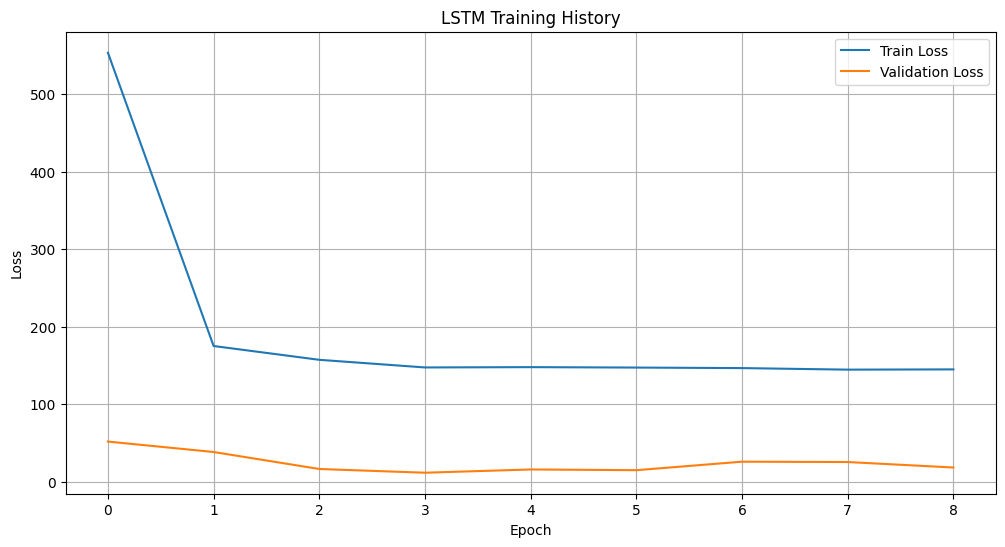

In [32]:
# LOSS CURVES

plt.figure(figsize=(12,6))
plt.plot(history["train_loss"],label="Train Loss")
plt.plot(history["val_loss"],label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Training History")
plt.legend()
plt.grid(True)
plt.show()

In [40]:
test_index

DatetimeIndex(['2026-01-07 19:47:30', '2026-01-07 19:48:30',
               '2026-01-07 19:49:30', '2026-01-07 19:50:30',
               '2026-01-07 19:51:30', '2026-01-07 19:52:31',
               '2026-01-07 19:53:30', '2026-01-07 19:54:32',
               '2026-01-07 19:55:30', '2026-01-07 19:56:32',
               ...
               '2026-04-23 21:33:31', '2026-04-23 21:34:30',
               '2026-04-23 21:35:30', '2026-04-23 21:36:30',
               '2026-04-23 21:37:32', '2026-04-23 21:38:30',
               '2026-04-23 21:39:32', '2026-04-23 21:40:30',
               '2026-04-23 21:41:33', '2026-04-23 21:42:30'],
              dtype='datetime64[ns]', name='Date', length=140706, freq=None)

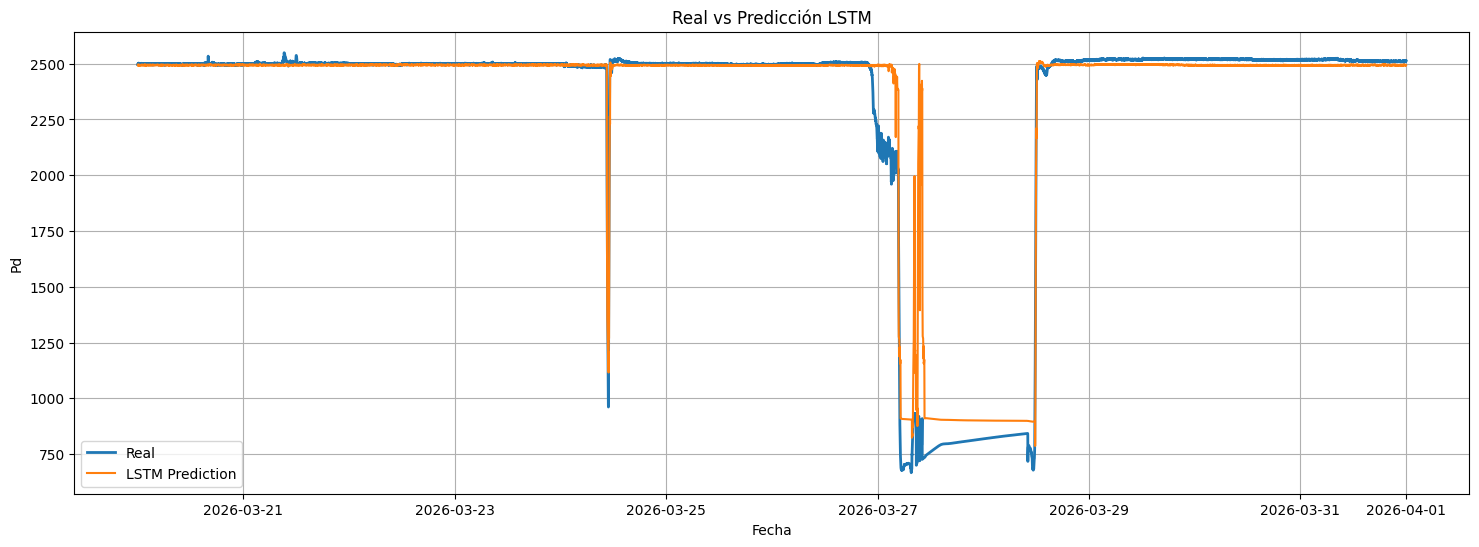

In [44]:
test_index = df_model.index[val_end + SEQ_LEN:]
fecha_inicio = '2026-03-20'
fecha_fin = '2026-04-01'
mask = (test_index >= fecha_inicio) & (test_index <= fecha_fin)

plt.figure(figsize=(18,6))
plt.plot(test_index[mask],y_real_lstm[mask],label="Real",linewidth=2)
plt.plot(test_index[mask],y_pred_lstm[mask],label="LSTM Prediction")

plt.title("Real vs Predicción LSTM")
plt.xlabel("Fecha")
plt.ylabel("Pd")
plt.legend()
plt.grid(True)

plt.show()

In [36]:
error = y_real_lstm - y_pred_lstm

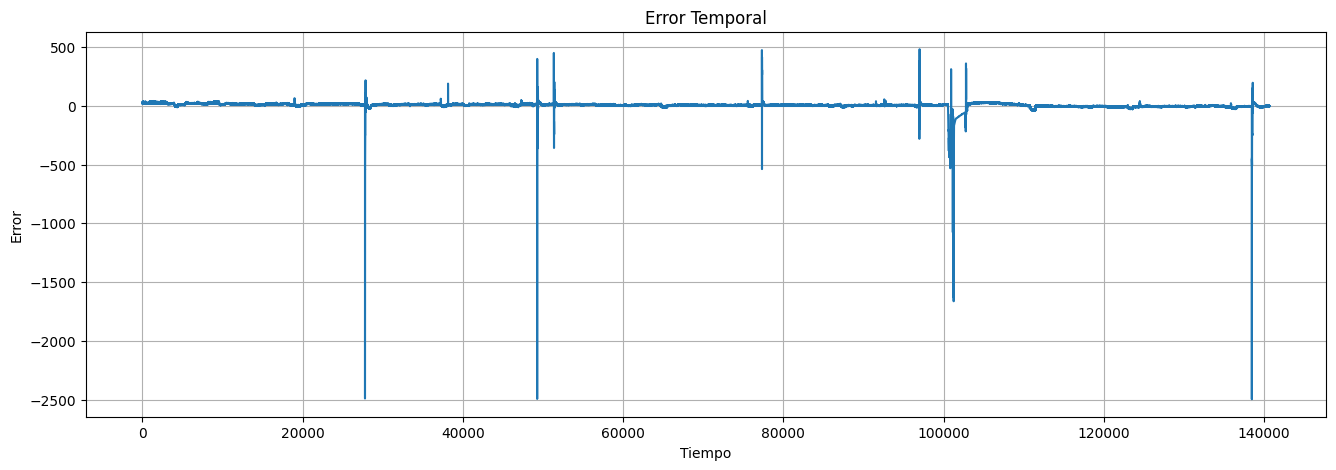

In [37]:
plt.figure(figsize=(16,5))
plt.plot(error)
plt.title("Error Temporal")
plt.xlabel("Tiempo")
plt.ylabel("Error")
plt.grid(True)
plt.show()

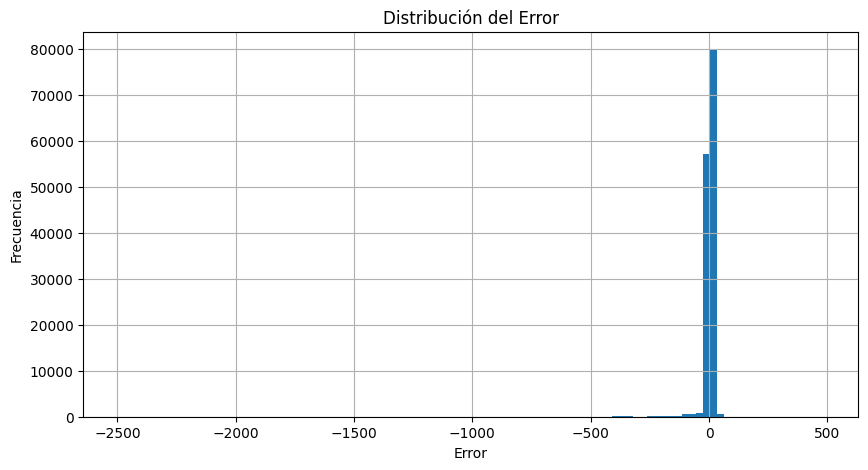

In [38]:
plt.figure(figsize=(10,5))
plt.hist(error,bins=100)
plt.title("Distribución del Error")
plt.xlabel("Error")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.show()

### Guardar Modelo

In [46]:
torch.save(model.state_dict(),"lstm_pd_model.pth")
# Guardar scaler
joblib.dump(scaler_X, "scaler_X.pkl")

['scaler_X.pkl']

### Cargar modelo

In [ ]:
# primero crear modelo
input_size = len(features)
model = LSTMModel(input_size=input_size,hidden_size=128,num_layers=2,dropout=0.2)
model.load_state_dict(torch.load("lstm_pd_model.pth"))

model.eval()

scaler_X = joblib.load("scaler_X.pkl")